<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/4.4-training-building-a-cnn-mfccs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Implementación de Unidad Recurrente Bidireccional con Compuerta (BiGRU) Para Tensores Basados en MFCC.

In this notebook vamos a levar a cabo el uso de una *Bidirectional gated recurrent Unit* por sus siglas en ingles *BiGRU*, es una variante avanzada de las Redes Neuronales Recurrentes (RNN) que mejora el procesamiento de secuencias al analizar los datos en ambas direcciones: de principio a fin (hacia adelante) y de fin a principio (hacia atrás). Esta arquitectura combina dos capas de Unidades Recurrentes con Compuerta (GRU) independientes para capturar el contexto tanto pasado como futuro de cada elemento en una secuencia. Para sacar provecho de los canales que conservan la dimension temporal en nuestros tensores, that is los canales correspondientes al delta de MFCC y delta ($\Delta$) , de segundo orden ($\Delta^2$).

It should be noted that, para las primeros bloques de la arquitectura de la Red Neuronal, se usan unidades estandar del tipo Convolusional, de manera que, nuestra arquitectura posee la siguiente estructura base:

## Monitoreo con Weights & Biases

Para optimizar el rendimiento de nuestra arquitectura CBGRU (CNN + BiGRU), integramos Weights & Biases (W&B) como plataforma central de experimentación. En modelos híbridos complejos, es crítico entender cómo interactúan las capas convolucionales y las recurrentes.

**Seguimiento (Tracking)**: Registro en tiempo real de métricas (pérdida, precisión), hiperparámetros y consumo de hardware (GPU/CPU).

**Visualización**: Tableros interactivos para comparar ejecuciones y analizar el rendimiento del modelo.

**Artefactos**: Control de versiones para datasets y modelos, garantizando la trazabilidad y reproducibilidad.

**Barrido (Sweeps)**: Automatización de la búsqueda de los mejores hiperparámetros para optimizar el modelo.

El objetivo es:

* Registrar cada ejecución (hiperparámetros + métricas + artefactos)

* Seleccionar el mejor punto de control usando solo la validación.

* Evaluar una sola vez al final para evitar la fuga de datos de las pruebas.

* Constatar la evolución de los modelos y sus diferentes arquitecturas.

* Obener un modelo final para su inferencia y despliegue a partir de la verificación de su rendimiento despúes de la respectiva experimentación.


### 1.0 Imports y configuración base


In [12]:
# Imports
#------------------------------------------------------------------------------------------
import os
import copy
import numpy as np
import torch
import xgboost as xgb
import random as random
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import time
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torchaudio import transforms as T
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay,f1_score, accuracy_score)
from google.colab import drive
from tqdm import tqdm
from collections import Counter

In [2]:
# ─── Instalación de Weights & Biases ────────────────────────────────
# Descomenta las líneas siguientes si wandb no está instalado en tu entorno:
!pip install wandb -q

# Para autenticarte (solo la primera vez por sesión de Colab):
import wandb; wandb.login()

# USE_WANDB se define en la celda de configuración más abajo.
# Déjalo en False para ejecutar sin tracking remoto.

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: acsalazar (acsalazar-numbral) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
# Semilla y runtime
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


### 1.2 Carga de tensores desde Drive (train/val/test)

Los archivos `.pt` generados en el notebook 3.2 contienen un diccionario con `x`, `y`,
metadatos y el mapeo de clases. Ajusta `BASE_DIR_TENSOR` según tu ruta local/Drive.


In [5]:
drive.mount('/content/drive')
! cp -r /content/drive/MyDrive/split_pytorch_tensors_mfcc /content/split_pytorch_tensors

Mounted at /content/drive


In [6]:
BASE_DIR_TENSOR = '/content/split_pytorch_tensors'
BATCH_SIZE = 32

SPLIT_FILES = {
    'train': 'train_tensors.pt',
    'val': 'val_tensors.pt',
    'test': 'test_tensors.pt',
}

def load_pack(split_name: str):
    path = os.path.join(BASE_DIR_TENSOR, SPLIT_FILES[split_name])
    if not os.path.exists(path):
        raise FileNotFoundError(f'No existe el archivo: {path}')
    return torch.load(path, map_location='cpu', weights_only=False)

# Cargamos lo packs en variables aun no son tensores puros
train_pack = load_pack('train')
val_pack = load_pack('val')
test_pack = load_pack('test')

# Verificamos las clases del diccionario dentro del pack
class_to_idx = train_pack['class_to_idx']
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]
print('Clases:', class_names)
print('Shape train:', tuple(train_pack['x'].shape))

Clases: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Shape train: (7422, 3, 13, 51)


### 1.3 Estrategia de normalización y augmentation

**Normalización:**  
Los tensores provienen del notebook `3.2` y ya fueron normalizados con **z-score por muestra y canal** (`zscore_per_channel`). No se aplica una segunda normalización a nivel de dataset para evitar doble normalización.

**Augmentation online (desactivado por defecto):**  
El notebook `3.2` ya añadió muestras extra de `surprised` con **ruido** y **shift temporal** durante la exportación (augmentación *offline*). Por eso `augment=False` es el valor por defecto en `build_dataloaders`: la augmentación offline ya aporta robustez sin el riesgo de distorsionar demasiado las entradas.  
Si se desea augmentación online adicional, se puede activar `augment=True`; en ese caso se aplica exclusivamente **SpecAugment** (FrequencyMasking + TimeMasking), más un pequeño ruido gaussiano opcional.

**Early stopping y scheduler:**  
Se usa **macro-F1** como criterio en lugar de `val_loss`, ya que es más informativo para datasets desbalanceados y refleja mejor el objetivo de clasificación equitativa entre clases.


In [7]:
class TensorPackDataset(Dataset):
  def __init__(self, pack, augment=False):
      self.x = pack['x'].float() # [N, 3, n_mfcc, targetframes]
      self.y = pack['y'].long()  # len(N)
      self.augment = augment

      # Definimos las transformaciones de SpecAugment
      # Ajustar n_freq_masks y n_time_masks según el tamaño (13x51)
      if augment:
          self.spec_aug = nn.Sequential(
              T.FrequencyMasking(freq_mask_param=3), # Enmascara hasta 4 bins de mel
              T.TimeMasking(time_mask_param=1)       # Enmascara hasta 2 frames de tiempo
          )

  def __len__(self):
      return self.y.shape[0]

  def __getitem__(self, idx):
      x = self.x[idx]
      y = self.y[idx]

      if self.augment:
          # SpecAugment espera [batch, channel, freq, time] o [channel, freq, time]
          # Aplicamos la misma máscara a los 3 canales (MFCC, Delta, Delta2)
          x = self.spec_aug(x)
          '''
          # Opcional: Pequeño ruido gaussiano
          if random.random() < 0.5:
              x = x + 0.01 * torch.randn_like(x)'''

      return x, y

### 1.4 Configuracion Early Stop

In [8]:
class EarlyStopping:
    """Early stopping configurable para minimizar (val_loss) o maximizar (val_f1)."""
    def __init__(self, patience=5, min_delta=0.0, mode="min"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode  # "min" para loss, "max" para F1
        self.best = None
        self.counter = 0

    def step(self, metric):
        """Devuelve True cuando se debe detener el entrenamiento."""
        if self.best is None:
            self.best = metric
            return False
        improved = (metric > self.best + self.min_delta) if self.mode == "max" \
                   else (metric < self.best - self.min_delta)
        if improved:
            self.best = metric
            self.counter = 0
            return False
        self.counter += 1
        print(f"Early Stopping: {self.counter}/{self.patience} (best={self.best:.4f})")
        return self.counter >= self.patience


### 1.5 Dataloaders

In [9]:
# Solo aumentamos el set de TRAIN. Val y Test deben quedar puros.
def build_dataloaders(batch_size=BATCH_SIZE):
    pin = torch.cuda.is_available()
    # Valor por defecto: augment= False
    train_ds = TensorPackDataset(train_pack, augment=False)
    val_ds = TensorPackDataset(val_pack, augment=False)
    test_ds = TensorPackDataset(test_pack, augment=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=pin)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = build_dataloaders()


### 1.6 Definición de la CGRU


In [10]:
class EmotionCGRU(nn.Module):
    def __init__(self, num_classes, classifier_dropout=0.5):
        super().__init__()

        # Entrada esperada: (Batch, 3, 13, 51)
        self.cnn = nn.Sequential(
            # Bloque Convolucional 1
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            # Reducimos frecuencia suavemente, mantenemos tiempo intacto
            nn.MaxPool2d(kernel_size=(2, 1)), # Frec: 13 -> 6, Tiempo: 51 -> 51

            # Bloque Convolucional 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)), # Frec: 6 -> 3, Tiempo: 51 -> 51
            nn.Dropout2d(0.1),

            # Bloque Convolucional 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.25)
            # Salida de CNN: (Batch, 64, 3, 51)
        )

        # 64 canales * 3 bins de frecuencia restantes = 192 features por frame
        self.gru_input_size = 64 * 3

        self.bigru = nn.GRU(
            input_size=self.gru_input_size,
            hidden_size=64,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.25
        )

        self.classifier = nn.Sequential(
            # 64 * 2 porque la GRU es bidireccional
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(classifier_dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # 1. Extracción de características CNN
        x = self.cnn(x)

        batch_size, channels, freq, time = x.size()

        # 2. Formatear para GRU: (Batch, Tiempo, Features)
        # Permutamos a (Batch, Tiempo, Canales, Frecuencia) -> (Batch, 51, 64, 3)
        x = x.permute(0, 3, 1, 2).contiguous()
        # Aplanamos a (Batch, 51, 192)
        x = x.view(batch_size, time, channels * freq)

        # 3. Modelado Secuencial
        gru_out, _ = self.bigru(x)

        # 4. Pooling temporal (promedio) y clasificación
        x = gru_out.mean(dim=1)
        return self.classifier(x)

## Tracking con Weights & Biases (W&B)

En los cuadernos de Colab/Jupyter, volver a ejecutar las celdas a menudo sobrescribe variables y resultados, lo que facilita la pérdida de:

* Qué hiperparámetros produjeron el mejor modelo y
las curvas de entrenamiento completas (pérdida/F1 vs. época).

* El mejor punto de control para esa ejecución, la matriz de confusión y
informe de clasificación asociado a ese punto de control.

***W&B*** soluciona esto almacenando las ejecuciones en un registro de experimentos externo, donde cada ejecución incluye:

1. Aspectos de la configuración `(wandb.config)` como for example: `dropout`,`seeds`,`weight decay`,`Learnig rate`, etc.

2. La serie temporal de métricas por época `train val loss`, `macro-F1`, `LR`.

3. Artefactos como puntos de control del modelo e informes.

### 2.0 Configuración de W&B

El baseline se contruye a partir de experimentacion anterior donde se obtuvo mayor estabilidad con un `BATCH_SIZE=32`, y como mencionamos antes sin *online data augmentation*, aunque se conservan estas funcionalidades con motivos investigativos, para futuros usuarios.

In [11]:
# --- Configuración de W&B y matriz de experimentos -----------------------------

# Establece USE_WANDB = True para registrar experimentos en Weights & Biases.
# Requiere wandb instalado (!pip install wandb -q) y autenticado con API key.
USE_WANDB      = True                # ← cambiar a True para activar tracking
WANDB_PROJECT  = "tcoe-experiments-no-aug-mfccs"
WANDB_GROUP    = "cnn-cgru-batch32-2.2"  # agrupa los cuatro experimentos en la misma vista (Mul útil)

# --- Hiperparámetros que son fijos en los cuatro experimentos-------------------

# Baseline confirmado: BATCH_SIZE=32, augment=False (sin SpecAugment online),

EPOCHS              = 50
LABEL_SMOOTHING     = 0.05
MAX_GRAD_NORM       = 1.0
EARLY_STOP_PATIENCE = 8    # patience mayor para que los drops de LR tomen efecto, no usar un valor menor a 4

# Directorio local para guardar los mejores checkpoints por ejecucion
CHECKPOINT_DIR = '/content/checkpoints_cnn'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# --- Matriz de experimentos (4 ejecuciones) ------------------------------------
# Scheduler fijo: ReduceLROnPlateau(mode='max', factor=0.5, patience=2) sobre val macro-F1.
# Gradient clipping: max_norm=1.0.  Label smoothing: 0.05.

RUN_MATRIX = [
    # Run 1 — baseline fuerte: LR conservador, dropout estándar, pesos de clase
    {
        "run_name": "run1_lr3e4_wd1e3_do05_cw",
        "lr": 3e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.5,
        "use_class_weights": True,
    },
    # Run 2 — LR más alto: explorar convergencia más rápida
    {
        "run_name": "run2_lr5e4_wd1e3_do05_cw",
        "lr": 5e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.6,
        "use_class_weights": False,
    },
    # Run 3 — dropout reducido: menos regularización en el clasificador
    {
        "run_name": "run3_lr3e4_wd1e3_do03_cw",
        "lr": 3e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.3,
        "use_class_weights": True,
    },
    # Run 4 — diagnóstico: sin pesos de clase (mide impacto del balanceo)
    {
        "run_name": "run4_lr3e4_wd1e3_do05_nocw",
        "lr": 3e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.5,
        "use_class_weights": False,
    },
]


### 4. Entrenamiento y validación


In [13]:
# TRAIN
#-------------------------------------------------------------------------------
# Calcular pesos de clase: total / (n_clases * counts)
# Esto da más peso a las clases con menos muestras.
''''surprised' tiene muestras extra desde la exportación offline, por lo que su peso
    resultante será menor que otras clases sub-representadas.'''

y_train_cpu = train_pack['y'].numpy()
label_counts = Counter(y_train_cpu)
total_samples = len(y_train_cpu)
num_classes = len(class_names)

class_weights = []
for i in range(num_classes):
    count = label_counts.get(i, 1)
    weight = total_samples / (num_classes * count)
    class_weights.append(weight)

class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print(f"Pesos calculados para CrossEntropyLoss: {class_weights}")


def train_one_epoch(model, loader, criterion, optimizer, device, epoch=None, max_grad_norm=1.0):
    model.train()
    running_loss = 0.0
    running_correct = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch:02d} [train]", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        # Gradient clipping para estabilizar el entrenamiento del GRU
        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_correct / len(loader.dataset)
    return epoch_loss, epoch_acc


# VAL
#-------------------------------------------------------------------------------
@torch.no_grad()
def evaluate(model, loader, criterion, device, epoch=None):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    all_preds, all_targets = [], []

    pbar = tqdm(loader, desc=f"Epoch {epoch:02d} [val]", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * inputs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_targets.extend(labels.cpu().numpy())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_correct / len(loader.dataset)
    # Macro-F1: métrica clave para datasets desbalanceados con objetivo de clasificación equitativa
    epoch_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    return epoch_loss, epoch_acc, epoch_f1


# TEST / PREDICCIONES
#-------------------------------------------------------------------------------
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    for inputs, labels in loader:
        outputs = model(inputs.to(device))
        all_preds.append(outputs.argmax(1).cpu().numpy())
        all_targets.append(labels.numpy())
    return np.concatenate(all_targets), np.concatenate(all_preds)


Pesos calculados para CrossEntropyLoss: [0.896268566598237, 0.896268566598237, 0.896268566598237, 0.896268566598237, 0.9647731704146627, 0.896268566598237, 2.5987394957983194]



  INICIANDO: run1_lr3e4_wd1e3_do05_cw
  lr=0.0003  wd=0.001  dropout=0.5  class_weights=True



[23:31:01] Epoca 01/50 | Train loss 1.8410 acc 0.2542 | Val loss 1.7128 acc 0.3541 f1 0.3284 | lr 3.0e-04 | Time 4.6s


[23:31:04] Epoca 02/50 | Train loss 1.6799 acc 0.3331 | Val loss 1.6541 acc 0.3481 f1 0.3016 | lr 3.0e-04 | Time 2.5s
Early Stopping: 1/8 (best=0.3284)


[23:31:06] Epoca 03/50 | Train loss 1.6129 acc 0.3580 | Val loss 1.5975 acc 0.3840 f1 0.3445 | lr 3.0e-04 | Time 2.4s


[23:31:09] Epoca 04/50 | Train loss 1.5598 acc 0.3810 | Val loss 1.5534 acc 0.4127 f1 0.3678 | lr 3.0e-04 | Time 2.5s


...

[23:32:49] Epoca 41/50 | Train loss 1.0363 acc 0.6551 | Val loss 1.4323 acc 0.5634 f1 0.5552 | lr 1.9e-05 | Time 2.8s
Early Stopping: 4/8 (best=0.5715)


[23:32:51] Epoca 42/50 | Train loss 1.0311 acc 0.6572 | Val loss 1.4151 acc 0.5622 f1 0.5543 | lr 1.9e-05 | Time 2.4s
Early Stopping: 5/8 (best=0.5715)


[23:32:54] Epoca 43/50 | Train loss 1.0278 acc 0.6532 | Val loss 1.4292 acc 0.5598 f1 0.5529 | lr 9.4e-06 | Time 2.5s
Early Stopping: 6/8 (best=0.5715)


[23:32:56] Epoca 44/50 | Train loss 1.0311 acc 0.6607 | Val loss 1.4267 acc 0.5622 f1 0.5552 | lr 9.4e-06 | Time 2.5s
Early Stopping: 7/8 (best=0.5715)


[23:32:59] Epoca 45/50 | Train loss 1.0300 acc 0.6605 | Val loss 1.4205 acc 0.5598 f1 0.5526 | lr 9.4e-06 | Time 2.9s
Early Stopping: 8/8 (best=0.5715)
Early stopping en epoch 45 (best val_f1=0.5715)

--- RESULTADO TEST [run1_lr3e4_wd1e3_do05_cw] ---
  best_epoch=37  best_val_f1=0.5715
  test_macro_f1=0.5788  test_acc=0.5670
              precision    recall  f1-score   support

       angry       0.62      0.77      0.69       144
     disgust       0.48      0.47      0.47       144
     fearful       0.51      0.40      0.45       144
       happy       0.52      0.46      0.49       144
     neutral       0.60      0.78      0.68       144
         sad       0.57      0.51      0.54       144
   surprised       0.84      0.66      0.74        32

    accuracy                           0.57       896
   macro avg       0.59      0.58      0.58       896
weighted avg       0.56      0.57      0.56       896



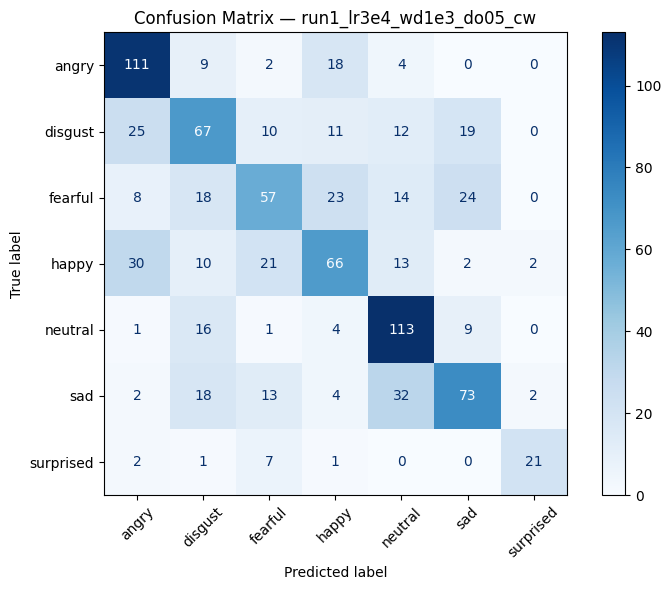

lr,████████████████████▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▁▁▁▁▁
test_acc,▁
test_macro_f1,▁
train_acc,▁▂▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇██▇███████████
train_loss,█▇▆▆▅▅▅▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▂▃▃▃▄▅▄▅▅▆▅▅▆▆▆▇▇▆▇▇█▇▇████▇█▇██████▇▇
val_loss,█▇▆▅▅▅▄▃▃▃▃▁▃▂▁▂▂▁▁▂▂▁▁▂▂▂▂▂▁▂▂▂▂▂▂▂▂▂▂▂
val_macro_f1,▂▁▂▃▃▃▄▄▅▅▅▆▅▅▇▆▆▇▇▇▇▇██▇████▇██████████
lr,1e-05
test_acc,0.56696
test_macro_f1,0.57875



  INICIANDO: run2_lr5e4_wd1e3_do05_cw
  lr=0.0005  wd=0.001  dropout=0.6  class_weights=False



[23:33:07] Epoca 01/50 | Train loss 1.8562 acc 0.2691 | Val loss 1.6695 acc 0.3684 f1 0.3177 | lr 5.0e-04 | Time 2.7s


[23:33:10] Epoca 02/50 | Train loss 1.6627 acc 0.3628 | Val loss 1.5948 acc 0.3804 f1 0.3387 | lr 5.0e-04 | Time 2.7s


[23:33:13] Epoca 03/50 | Train loss 1.6090 acc 0.3704 | Val loss 1.5633 acc 0.3983 f1 0.3685 | lr 5.0e-04 | Time 2.9s


...

[23:34:29] Epoca 29/50 | Train loss 1.0736 acc 0.6605 | Val loss 1.4218 acc 0.5239 f1 0.5133 | lr 6.3e-05 | Time 2.7s
Early Stopping: 4/8 (best=0.5282)


[23:34:32] Epoca 30/50 | Train loss 1.0766 acc 0.6621 | Val loss 1.4288 acc 0.5299 f1 0.5166 | lr 6.3e-05 | Time 2.6s
Early Stopping: 5/8 (best=0.5282)


[23:34:35] Epoca 31/50 | Train loss 1.0535 acc 0.6672 | Val loss 1.4380 acc 0.5132 f1 0.5054 | lr 3.1e-05 | Time 2.7s
Early Stopping: 6/8 (best=0.5282)


[23:34:38] Epoca 32/50 | Train loss 1.0578 acc 0.6605 | Val loss 1.4112 acc 0.5167 f1 0.5074 | lr 3.1e-05 | Time 3.2s
Early Stopping: 7/8 (best=0.5282)


[23:34:41] Epoca 33/50 | Train loss 1.0607 acc 0.6710 | Val loss 1.4345 acc 0.5203 f1 0.5098 | lr 3.1e-05 | Time 3.5s
Early Stopping: 8/8 (best=0.5282)
Early stopping en epoch 33 (best val_f1=0.5282)

--- RESULTADO TEST [run2_lr5e4_wd1e3_do05_cw] ---
  best_epoch=25  best_val_f1=0.5282
  test_macro_f1=0.5459  test_acc=0.5357
              precision    recall  f1-score   support

       angry       0.56      0.81      0.66       144
     disgust       0.50      0.39      0.44       144
     fearful       0.49      0.28      0.36       144
       happy       0.48      0.49      0.49       144
     neutral       0.54      0.73      0.62       144
         sad       0.56      0.49      0.52       144
   surprised       0.84      0.66      0.74        32

    accuracy                           0.54       896
   macro avg       0.57      0.55      0.55       896
weighted avg       0.53      0.54      0.52       896



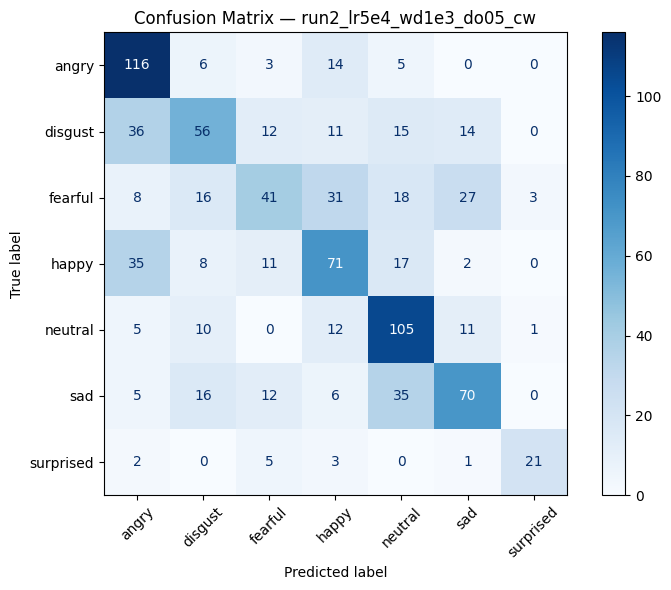

lr,███████████████████▄▄▄▄▂▂▂▂▁▁▁▁▁▁
test_acc,▁
test_macro_f1,▁
train_acc,▁▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇████████
train_loss,█▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▂▂▃▃▂▄▅▄▆▆▇▇▅▆▇▇▇▆▇█▇▆████▇██▇▇▇
val_loss,█▆▆▅▅▇▄▄▅▃▃▂▂▃▃▁▂▂▃▂▂▂▄▂▂▂▃▃▂▃▃▂▃
val_macro_f1,▁▂▃▄▃▃▄▄▄▆▆▆▇▆▇▇█▇▆▇█▇▇▇███▇██▇▇▇
lr,3e-05
test_acc,0.53571
test_macro_f1,0.54588



  INICIANDO: run3_lr3e4_wd1e3_do03_cw
  lr=0.0003  wd=0.001  dropout=0.3  class_weights=True



[23:34:50] Epoca 01/50 | Train loss 1.7993 acc 0.2708 | Val loss 1.6968 acc 0.3636 f1 0.3134 | lr 3.0e-04 | Time 2.9s


[23:34:53] Epoca 02/50 | Train loss 1.6365 acc 0.3517 | Val loss 1.6443 acc 0.3600 f1 0.3139 | lr 3.0e-04 | Time 3.2s


[23:34:57] Epoca 03/50 | Train loss 1.5737 acc 0.3786 | Val loss 1.6065 acc 0.3864 f1 0.3464 | lr 3.0e-04 | Time 3.4s


...

[23:36:33] Epoca 34/50 | Train loss 1.0088 acc 0.6591 | Val loss 1.4195 acc 0.5407 f1 0.5299 | lr 3.7e-05 | Time 2.7s
Early Stopping: 4/8 (best=0.5549)


[23:36:36] Epoca 35/50 | Train loss 1.0015 acc 0.6683 | Val loss 1.4140 acc 0.5562 f1 0.5491 | lr 3.7e-05 | Time 2.7s
Early Stopping: 5/8 (best=0.5549)


[23:36:39] Epoca 36/50 | Train loss 1.0079 acc 0.6659 | Val loss 1.4098 acc 0.5562 f1 0.5464 | lr 1.9e-05 | Time 2.7s
Early Stopping: 6/8 (best=0.5549)


[23:36:42] Epoca 37/50 | Train loss 0.9943 acc 0.6726 | Val loss 1.4114 acc 0.5478 f1 0.5395 | lr 1.9e-05 | Time 3.2s
Early Stopping: 7/8 (best=0.5549)


[23:36:45] Epoca 38/50 | Train loss 0.9900 acc 0.6727 | Val loss 1.4106 acc 0.5526 f1 0.5402 | lr 1.9e-05 | Time 3.3s
Early Stopping: 8/8 (best=0.5549)
Early stopping en epoch 38 (best val_f1=0.5549)

--- RESULTADO TEST [run3_lr3e4_wd1e3_do03_cw] ---
  best_epoch=30  best_val_f1=0.5549
  test_macro_f1=0.5822  test_acc=0.5792
              precision    recall  f1-score   support

       angry       0.59      0.82      0.69       144
     disgust       0.58      0.46      0.51       144
     fearful       0.53      0.33      0.41       144
       happy       0.57      0.56      0.57       144
     neutral       0.56      0.82      0.67       144
         sad       0.57      0.49      0.52       144
   surprised       0.95      0.56      0.71        32

    accuracy                           0.58       896
   macro avg       0.62      0.58      0.58       896
weighted avg       0.58      0.58      0.57       896



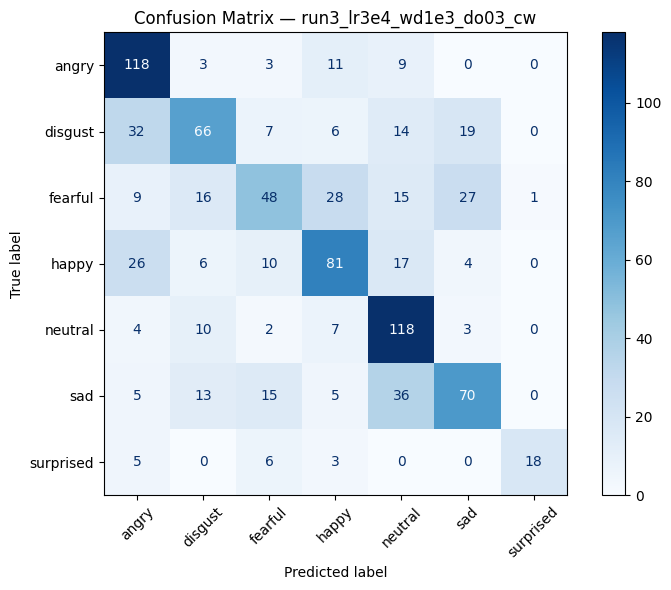

lr,████████████████████▄▄▄▄▂▂▂▂▂▂▂▂▁▁▁▁▁▁
test_acc,▁
test_macro_f1,▁
train_acc,▁▂▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇███████████
train_loss,█▇▆▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▂▃▄▃▃▄▄▅▆▆▆▅▇▆▆▇▇▆▆▇▆▇▇▇▇▇██▇▇▇▇██▇█
val_loss,█▇▆▄▃▅▄▃▃▂▂▁▁▃▂▂▁▁▂▂▁▂▃▂▂▂▂▂▁▁▁▁▂▂▂▁▂▂
val_macro_f1,▁▁▂▃▄▃▃▄▄▅▆▆▇▆▇▆▇▇▇▆▆▇▆▇▇▇▇▇██▇▇▇▇████
lr,2e-05
test_acc,0.57924
test_macro_f1,0.5822



  INICIANDO: run4_lr3e4_wd1e3_do05_nocw
  lr=0.0003  wd=0.001  dropout=0.5  class_weights=False



[23:36:53] Epoca 01/50 | Train loss 1.9041 acc 0.2545 | Val loss 1.7102 acc 0.3529 f1 0.2705 | lr 3.0e-04 | Time 2.9s


[23:36:56] Epoca 02/50 | Train loss 1.7268 acc 0.3275 | Val loss 1.6044 acc 0.3816 f1 0.3378 | lr 3.0e-04 | Time 2.9s


[23:36:59] Epoca 03/50 | Train loss 1.6461 acc 0.3623 | Val loss 1.5679 acc 0.4043 f1 0.3651 | lr 3.0e-04 | Time 3.2s


...

[23:37:43] Epoca 17/50 | Train loss 1.2740 acc 0.5493 | Val loss 1.3291 acc 0.5347 f1 0.5319 | lr 1.5e-04 | Time 3.3s
Early Stopping: 4/8 (best=0.5340)


[23:37:46] Epoca 18/50 | Train loss 1.2600 acc 0.5587 | Val loss 1.3442 acc 0.5335 f1 0.5291 | lr 1.5e-04 | Time 2.8s
Early Stopping: 5/8 (best=0.5340)


[23:37:48] Epoca 19/50 | Train loss 1.2507 acc 0.5691 | Val loss 1.3460 acc 0.5227 f1 0.5156 | lr 7.5e-05 | Time 2.7s
Early Stopping: 6/8 (best=0.5340)


[23:37:51] Epoca 20/50 | Train loss 1.2307 acc 0.5790 | Val loss 1.3579 acc 0.5191 f1 0.5086 | lr 7.5e-05 | Time 2.8s
Early Stopping: 7/8 (best=0.5340)


[23:37:55] Epoca 21/50 | Train loss 1.2199 acc 0.5822 | Val loss 1.3487 acc 0.5287 f1 0.5210 | lr 7.5e-05 | Time 3.4s
Early Stopping: 8/8 (best=0.5340)
Early stopping en epoch 21 (best val_f1=0.5340)

--- RESULTADO TEST [run4_lr3e4_wd1e3_do05_nocw] ---
  best_epoch=13  best_val_f1=0.5340
  test_macro_f1=0.5308  test_acc=0.5223
              precision    recall  f1-score   support

       angry       0.60      0.74      0.66       144
     disgust       0.39      0.52      0.45       144
     fearful       0.45      0.34      0.39       144
       happy       0.46      0.44      0.45       144
     neutral       0.62      0.60      0.61       144
         sad       0.60      0.50      0.55       144
   surprised       0.80      0.50      0.62        32

    accuracy                           0.52       896
   macro avg       0.56      0.52      0.53       896
weighted avg       0.53      0.52      0.52       896



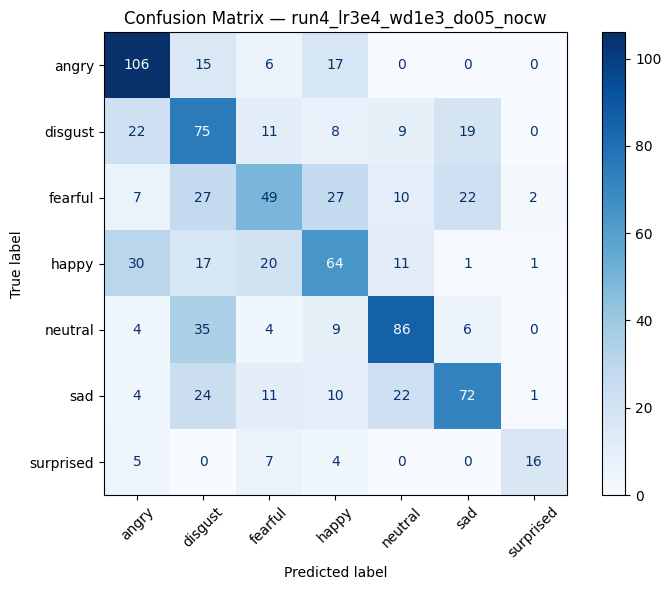

lr,███████████████▃▃▃▁▁▁
test_acc,▁
test_macro_f1,▁
train_acc,▁▃▃▄▄▅▅▅▅▆▆▆▇▇▇▇▇▇███
train_loss,█▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁
val_acc,▁▂▃▄▃▅▅▅▄▅▇▇█▆████▇▇█
val_loss,█▆▅▄▄▄▃▃▄▃▂▂▁▃▁▁▁▁▁▂▁
val_macro_f1,▁▃▄▅▄▆▆▅▅▆▇▇█▆█████▇█
lr,7e-05
test_acc,0.52232
test_macro_f1,0.53078


In [14]:
# ─── Entrenamiento multi-experimento con W&B ──────────────────────────────────
all_run_results = []

for run_cfg in RUN_MATRIX:
    run_name           = run_cfg["run_name"]
    lr                 = run_cfg["lr"]
    weight_decay       = run_cfg["weight_decay"]
    classifier_dropout = run_cfg["classifier_dropout"]
    use_class_weights  = run_cfg["use_class_weights"]

    print(f"\n{'='*70}")
    print(f"  INICIANDO: {run_name}")
    print(f"  lr={lr}  wd={weight_decay}  dropout={classifier_dropout}  class_weights={use_class_weights}")
    print(f"{'='*70}\n")

    # Reproducibilidad por ejecucion
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)

    # Dataloaders frescos para cada ejecucion
    train_loader, val_loader, test_loader = build_dataloaders()

    # Modelo con el dropout del clasificador según la ejecucion
    model = EmotionCGRU(num_classes=len(class_names), classifier_dropout=classifier_dropout).to(device)

    # Función de pérdida
    criterion_weights = class_weights_tensor if use_class_weights else None
    criterion = nn.CrossEntropyLoss(weight=criterion_weights, label_smoothing=LABEL_SMOOTHING)

    # Optimizador y scheduler
    optimizer    = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler    = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    early_stopper = EarlyStopping(patience=EARLY_STOP_PATIENCE, min_delta=1e-4, mode='max')

    # Inicializar W&B
    if USE_WANDB:
        import wandb
        wandb.init(
            project=WANDB_PROJECT,
            group=WANDB_GROUP,
            name=run_name,
            config={
                "lr":                 lr,
                "weight_decay":       weight_decay,
                "classifier_dropout": classifier_dropout,
                "use_class_weights":  use_class_weights,
                "label_smoothing":    LABEL_SMOOTHING,
                "batch_size":         BATCH_SIZE,
                "epochs":             EPOCHS,
                "early_stop_patience": EARLY_STOP_PATIENCE,
                "max_grad_norm":      MAX_GRAD_NORM,
                "augment_online":     True,
                "model":              "EmotionCGRU",
            },
        )

    best_val_f1 = 0.0
    best_epoch  = 0
    best_state  = copy.deepcopy(model.state_dict())

    for epoch in range(1, EPOCHS + 1):
        start = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            epoch=epoch, max_grad_norm=MAX_GRAD_NORM,
        )
        val_loss, val_acc, val_f1 = evaluate(
            model, val_loader, criterion, device, epoch=epoch,
        )

        scheduler.step(val_f1)
        current_lr = optimizer.param_groups[0]['lr']
        elapsed = time.time() - start

        print(
            f"[{time.strftime('%H:%M:%S')}] Epoca {epoch:02d}/{EPOCHS:02d} | "
            f"Train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"Val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} | "
            f"lr {current_lr:.1e} | Time {elapsed:.1f}s"
        )

        if USE_WANDB:
            wandb.log({
                "train_loss":   train_loss,
                "train_acc":    train_acc,
                "val_loss":     val_loss,
                "val_acc":      val_acc,
                "val_macro_f1": val_f1,
                "lr":           current_lr,
            }, step=epoch)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch  = epoch
            best_state  = copy.deepcopy(model.state_dict())
            ckpt_path   = os.path.join(CHECKPOINT_DIR, f"{run_name}_best.pth")
            torch.save(best_state, ckpt_path)

        if early_stopper.step(val_f1):
            print(f"Early stopping en epoch {epoch} (best val_f1={best_val_f1:.4f})")
            break

    # ── Evaluación en test (una sola vez, con el mejor modelo por val_f1) ──────
    model.load_state_dict(best_state)
    y_true, y_pred = get_predictions(model, test_loader, device)
    test_f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    test_acc = accuracy_score(y_true, y_pred)

    print(f"\n--- RESULTADO TEST [{run_name}] ---")
    print(f"  best_epoch={best_epoch}  best_val_f1={best_val_f1:.4f}")
    print(f"  test_macro_f1={test_f1:.4f}  test_acc={test_acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax_cm, cmap='Blues', xticks_rotation=45, values_format='d')
    ax_cm.set_title(f"Confusion Matrix — {run_name}")
    plt.tight_layout()
    plt.show()

    if USE_WANDB:
        # Guardar y loggear el checkpoint como artefacto
        artifact = wandb.Artifact(name=f"model_{run_name}", type="model")
        artifact.add_file(ckpt_path)
        wandb.log_artifact(artifact)

        # Métricas y artefactos de test
        report_dict = classification_report(
            y_true, y_pred, target_names=class_names, output_dict=True)
        wandb.log({
            "test_macro_f1":       test_f1,
            "test_acc":            test_acc,
            "confusion_matrix":    wandb.Image(fig_cm),
            "classification_report": wandb.Table(
                columns=["class", "precision", "recall", "f1-score", "support"],
                data=[
                    [c,
                     report_dict[c]["precision"],
                     report_dict[c]["recall"],
                     report_dict[c]["f1-score"],
                     int(report_dict[c]["support"])]
                    for c in class_names
                ],
            ),
        })
        wandb.finish()

    all_run_results.append({
        "run_name":      run_name,
        "best_val_f1":   round(best_val_f1, 4),
        "best_epoch":    best_epoch,
        "test_macro_f1": round(test_f1, 4),
        "test_acc":      round(test_acc, 4),
    })
    plt.close('all')


### 5. Resumen de experimentos y evaluación final


In [15]:
# Tabla resumen de la experimentación -----------------------------------------------
summary_df = pd.DataFrame(all_run_results)
summary_df = summary_df.sort_values("best_val_f1", ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("  RESUMEN FINAL DE EXPERIMENTOS")
print("="*70)
print(summary_df.to_string(index=False))
display(summary_df)



  RESUMEN FINAL DE EXPERIMENTOS
                  run_name  best_val_f1  best_epoch  test_macro_f1  test_acc
  run1_lr3e4_wd1e3_do05_cw       0.5715          37         0.5788    0.5670
  run3_lr3e4_wd1e3_do03_cw       0.5549          30         0.5822    0.5792
run4_lr3e4_wd1e3_do05_nocw       0.5340          13         0.5308    0.5223
  run2_lr5e4_wd1e3_do05_cw       0.5282          25         0.5459    0.5357


,run_name,best_val_f1,best_epoch,test_macro_f1,test_acc
0,run1_lr3e4_wd1e3_do05_cw,0.5715,37,0.5788,0.5670
1,run3_lr3e4_wd1e3_do03_cw,0.5549,30,0.5822,0.5792
2,run4_lr3e4_wd1e3_do05_nocw,0.5340,13,0.5308,0.5223
3,run2_lr5e4_wd1e3_do05_cw,0.5282,25,0.5459,0.5357
